In [1]:
from pathlib import Path
import numpy as np
import os, shutil
import matplotlib.pyplot as plt

from PIL import Image

from tqdm.auto import tqdm

import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
import torch.optim as optim

from torchvision.models import resnet50, ResNet50_Weights

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_image_path = Path('screw/train')

good_dataset = ImageFolder(root = train_image_path, transform = transform)
train_dataset, test_dataset = torch.utils.data.random_split(good_dataset, [0.8, 0.2])

BS = 16

train_loader = DataLoader(train_dataset, batch_size = BS, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BS, shuffle = True)

In [3]:
# resnet_model = resnet50(weights = ResNet50_Weights.DEFAULT)

# def hook(model, input, output):
#     feature.append(output.detach())

# feature = []

# resnet_model.layer2[-1].register_forward_hook(hook)
# resnet_model.layer3[-1].register_forward_hook(hook)

# _ = resnet_model(torch.randn(1, 3, 244, 244))


In [4]:
class resnet_feature_extractor(torch.nn.Module):
    def __init__(self):
        super(resnet_feature_extractor, self).__init__()
        self.model = resnet50(weights = ResNet50_Weights.DEFAULT)

        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False

        def hook(model, input, output) -> None:
            self.features.append(output)
        
        self.model.layer2[-1].register_forward_hook(hook)
        self.model.layer3[-1].register_forward_hook(hook)

    def forward(self, input):
        self.features = []
        with torch.no_grad():
            _ = self.model(input)

        self.avg = torch.nn.AvgPool2d(3, stride = 1)
        fmap_size = self.features[0].shape[-2]
        self.resize = torch.nn.AdaptiveAvgPool2d(fmap_size)

        resized_maps = [self.resize(self.avg(fmap)) for fmap in self.features]
        patch = torch.cat(resized_maps, 1)

        return patch

torch.Size([1, 512, 28, 28])
torch.Size([1, 1024, 14, 14])
torch.Size([1, 1536, 28, 28])


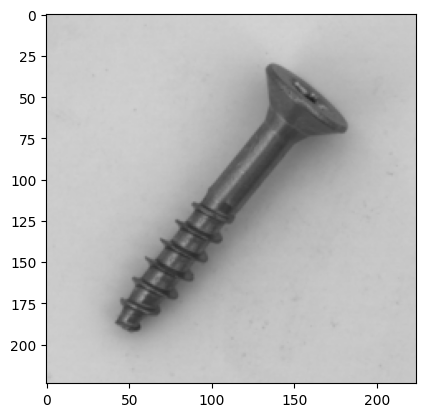

In [5]:
image = Image.open('screw/test/manipulated_front/000.png').convert('RGB')
image = transform(image).unsqueeze(0)

backbone = resnet_feature_extractor()
feature = backbone(image)

print(backbone.features[0].shape)
print(backbone.features[1].shape)

print(feature.shape)

plt.imshow(image[0].permute(1, 2, 0))


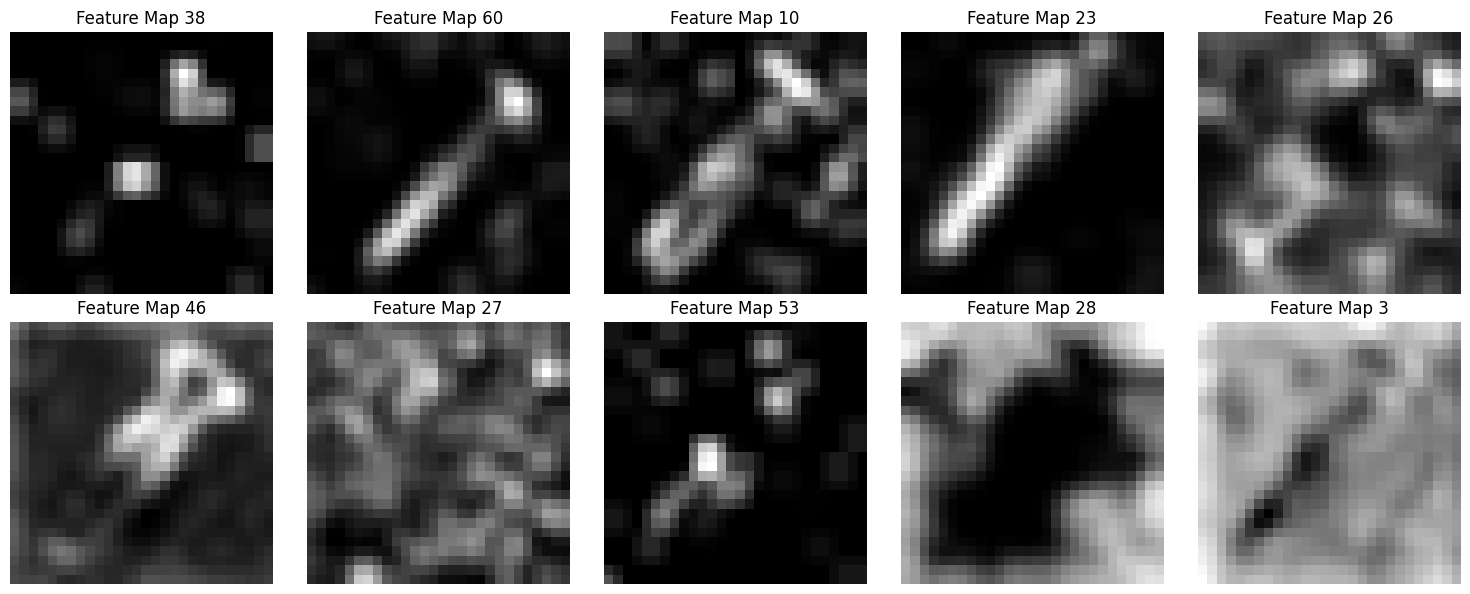

In [6]:
indices = torch.randperm(64)[:10]

fig, axes = plt.subplots(2, 5, figsize = (15, 6))
for i, idx in enumerate(indices):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(feature[0, idx].detach().cpu(), cmap = 'gray')
    axes[row, col].set_title(f'Feature Map {idx}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

the autoencoder part

In [7]:
# import torch.nn as nn

# class FeatCAE(nn.Module):

#     def __init__(self, in_channels = 1000, latent_dim = 50, is_bn = True):
#         super(FeatCAE, self).__init__()

#         layers = []
#         layers += [nn.Conv2d(in_channels, (in_channels + 2 * latent_dim) // 2, kernel_size = 1, stride = 1, padding = 0)]
#         if is_bn:
#             layers += [nn.BatchNorm2d(num_features = (in_channels + 2 * latent_dim) // 2)]
        
#         layers += [nn.ReLU()]
#         layers += [nn.Conv2d((in_channels + 2 * latent_dim) // 2, 2 * latent_dim, kernel_size = 1, stride = 1, padding = 0)]
#         if is_bn:
#             layers += [nn.BatchNorm2d(num_features = 2 * latent_dim)]
        
#         layers += [nn.ReLU()]
#         layers += [nn.Conv2d(2 * latent_dim, latent_dim, kernel_size = 1, stride = 1, padding = 0)]
        
#         self.encoder = nn.Sequential(*layers)

#         layers = []
#         layers += [nn.Conv2d(latent_dim, 2 * latent_dim, kernel_size = 1, stride = 1, padding = 0)]
#         if is_bn:
#             layers += [nn.BatchNorm2d(num_features = 2 * latent_dim)]
        
#         layers += [nn.ReLU()]
#         layers += [nn.Conv2d(2 * latent_dim, (in_channels + 2 * latent_dim) // 2, kernel_size = 1, stride = 1, padding = 0)]
#         if is_bn:
#             layers += [nn.BatchNorm2d(num_features = (in_channels + 2 * latent_dim) // 2)]
        
#         layers += [nn.ReLU()]
#         layers += [nn.Conv2d((in_channels + 2 * latent_dim) // 2, in_channels, kernel_size = 1, stride = 1, padding = 0)]

#         self.decoder = nn.Sequential(*layers)
    
#     def forward(self, x):
#         x = self.encoder(x)
#         x = self.decoder(x)
#         return x

In [ ]:
# gemini fixes
import torch.nn as nn

class FeatCAE(nn.Module):
    def __init__(self, in_channels = 1536, latent_dim = 100, is_bn = True):
        super(FeatCAE, self).__init__()

        # MENGGUNAKAN KERNEL 3x3 AGAR MODEL PAHAM BENTUK GLOBAL SEKRUP
        layers = []
        layers += [nn.Conv2d(in_channels, (in_channels + 2 * latent_dim) // 2, kernel_size=3, stride=1, padding=1)]
        if is_bn:
            layers += [nn.BatchNorm2d(num_features = (in_channels + 2 * latent_dim) // 2)]
        
        layers += [nn.ReLU()]
        layers += [nn.Conv2d((in_channels + 2 * latent_dim) // 2, 2 * latent_dim, kernel_size=3, stride=1, padding=1)]
        if is_bn:
            layers += [nn.BatchNorm2d(num_features = 2 * latent_dim)]
        
        layers += [nn.ReLU()]
        layers += [nn.Conv2d(2 * latent_dim, latent_dim, kernel_size=3, stride=1, padding=1)]
        
        self.encoder = nn.Sequential(*layers)

        layers = []
        layers += [nn.Conv2d(latent_dim, 2 * latent_dim, kernel_size=3, stride=1, padding=1)]
        if is_bn:
            layers += [nn.BatchNorm2d(num_features = 2 * latent_dim)]
        
        layers += [nn.ReLU()]
        layers += [nn.Conv2d(2 * latent_dim, (in_channels + 2 * latent_dim) // 2, kernel_size=3, stride=1, padding=1)]
        if is_bn:
            layers += [nn.BatchNorm2d(num_features = (in_channels + 2 * latent_dim) // 2)]
        
        layers += [nn.ReLU()]
        layers += [nn.Conv2d((in_channels + 2 * latent_dim) // 2, in_channels, kernel_size=3, stride=1, padding=1)]

        self.decoder = nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [9]:
model = FeatCAE(in_channels = 1536, latent_dim = 100)

criterion = torch.nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

NameError: name 'FeatCAE' is not defined

training loop

In [ ]:
# Loss = []
# Validation_loss = []

# num_epochs = 50
# backbone.eval()
# for epoch in tqdm(range(num_epochs)):

#     model.train()
#     for img, _ in train_loader:
#         with torch.no_grad():
#             feats = backbone(img)
        
#         output = model(feats)
#         loss = criterion(output, feats)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#     Loss.append(loss.item())

#     model.eval()
#     with torch.no_grad():
#         val_loss_sum = 0.0
#         num_batches = 0
#         for img, _ in test_loader:
#             feats = backbone(img)
#             output = model(feats)
#             val_loss = criterion(output, feats)
#             val_loss_sum += val_loss.item()
#             num_batches += 1
#         val_loss_avg = val_loss_sum / num_batches
#         Validation_loss.append(val_loss_avg)

#     if epoch % 5 == 0:
#         print("Epoch [{}/{}], Loss: {: 4f}, Validation Loss: {: 4f}".format(epoch + 1, num_epochs, loss.item(), val_loss_avg))  
    
# plt.plot(Loss, label = 'Training Loss')
# plt.plot(Validation_loss, label = 'Validation Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Training and Validation Loss')
# plt.legend()
# plt.show()

In [ ]:
# # save the model (kalo mau save, yang bawah (load) di comment dulu)

# torch.save(model.state_dict(), 'simple_autoencoder_resnet_screwdata.pth')
# model.eval()

In [ ]:
# load the model (kalo mau load, yg atas (save) di comment dulu)

checkpoint = torch.load('gemini_simple_autoencoder_resnet_screwdata.pth')
model.load_state_dict(checkpoint)

prediction heatmap

In [ ]:
image = Image.open('screw/test/scratch_head/000.png').convert('RGB')
image = transform(image).unsqueeze(0)

with torch.no_grad():
    feats = backbone(image)
    recon = model(feats)

recon_error = ((feats - recon) ** 2).mean(axis = (1)).unsqueeze(0)

segm_map = torch.nn.functional.interpolate(
    recon_error, 
    size = (224, 224), 
    mode = 'bilinear', 
    )

plt.imshow(segm_map.squeeze().cpu().numpy(), cmap = 'jet')
plt.show()

for ok images

In [ ]:
def decision_function(segm_map):

    mean_top_10_values = []

    for map in segm_map:
        flattened_tensor = map.reshape(-1)

        sorted_tensor, _ = torch.sort(flattened_tensor, descending = True)

        mean_top_10_value = sorted_tensor[:10].mean()
        mean_top_10_values.append(mean_top_10_value)

    return torch.stack(mean_top_10_values)

In [ ]:
# # gemini fixes
# def decision_function(segm_map):
#     scores = []
#     for map in segm_map:
#         flattened_tensor = map.reshape(-1)
        
#         # Ambil nilai max mutlak (untuk mendeteksi goresan tajam/scratches)
#         max_val = flattened_tensor.max()
        
#         # Ambil rata-rata keseluruhan (untuk mendeteksi bengkok/deformasi global)
#         mean_val = flattened_tensor.mean()
        
#         # Kombinasikan keduanya (bisa disesuaikan bobotnya jika perlu)
#         hybrid_score = max_val + (mean_val * 2) 
#         scores.append(hybrid_score)

#     return torch.stack(scores)

In [ ]:
model.eval()

RECON_ERROR = []
for data, _ in train_loader:

    with torch.no_grad():
        feats = backbone(data).squeeze()

        recon = model(feats)

    segm_map = ((feats - recon) ** 2).mean(axis = (1))[:,3:-3, 3:-3]
    anomaly_score = decision_function(segm_map)

    RECON_ERROR.append(anomaly_score)

RECON_ERROR = torch.cat(RECON_ERROR).cpu().numpy()


In [ ]:
best_threshold = np.mean(RECON_ERROR) + 3 * np.std(RECON_ERROR)

heat_map_max, heat_map_min = np.max(RECON_ERROR), np.min(RECON_ERROR)

plt.hist(RECON_ERROR, bins = 50)
plt.vlines(x = best_threshold, ymin = 0, ymax = 30, color = 'r')
plt.show()

for ng images

In [ ]:
y_true = []
y_pred = []
y_score = []

model.eval()
backbone.eval()
test_path = Path('screw/test')

for path in test_path.glob('*/*.png'):
    fault_type = path.parts[-2]
    test_image = transform(Image.open(path).convert('RGB')).unsqueeze(0)

    with torch.no_grad():
        feats = backbone(test_image)
        recon = model(feats)

    segm_map = ((feats - recon) ** 2).mean(axis = (1))[:,3:-3, 3:-3]
    y_score_image = decision_function(segm_map = segm_map)
    y_pred_image = 1 * (y_score_image > best_threshold)
    y_true_image = 0 if fault_type == 'good' else 1
    y_true.append(y_true_image)
    y_pred.append(y_pred_image.cpu().numpy())
    y_score.append(y_score_image.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

In [ ]:
plt.hist(y_score, bins = 50)
plt.vlines(x = best_threshold, ymin = 0, ymax = 30, color = 'r')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score
import seaborn as sns

auc_roc_score = roc_auc_score(y_true, y_score)
print("AUC-ROC Score: ", auc_roc_score)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
plt.figure()
plt.plot(fpr, tpr, color = 'darkorange', lw = 2, label = 'ROC curve (area = % 0.2f)' % auc_roc_score)
plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc = 'lower right')
plt.show()

f1_scores = [f1_score(y_true, y_score > threshold) for threshold in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f'best threshold: {best_threshold}')

cm = confusion_matrix(y_true, (y_score >= best_threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['OK', 'NG'])
disp.plot()
plt.show()

print out the predicition ont the test set

In [ ]:
# ini dia bakal tampilin beberapa data jejer ke bawah

# import cv2, time
# from IPython.display import display, clear_output

# model.eval()
# backbone.eval()

# test_path = Path('screw/test')

# for path in test_path.glob('*/*.png'):
#     fault_type = path.parts[-2]
#     test_image = transform(Image.open(path).convert('RGB')).unsqueeze(0)

#     with torch.no_grad():
#         feats = backbone(test_image)
#         recon = model(feats)

#     segm_map = ((feats - recon) ** 2).mean(axis = (1))[:,3:-3, 3:-3]
#     y_score_image = decision_function(segm_map = segm_map)
#     y_pred_image = (y_score_image > best_threshold).long()
#     class_label = ['OK', 'NG']

#     if fault_type in ['thread_top']: # tulis fault di sini

#         plt.figure(figsize = (15, 5))

#         plt.subplot(1, 3, 1)
#         plt.imshow(test_image.squeeze().permute(1, 2, 0).cpu().numpy())
#         plt.title(f'fault type: {fault_type}')

#         plt.subplot(1, 3, 2)
#         heat_map = segm_map.squeeze().cpu().numpy()
#         heat_map = cv2.resize(heat_map, (128, 128))
#         plt.imshow(heat_map, cmap = 'jet', vmin = heat_map_min, vmax = heat_map_max)
#         pred_label = class_label[int(y_pred_image.item())]
#         plt.title(f'Anomaly Score: {y_score_image.item() / best_threshold:0.4f} || {pred_label}')

#         plt.subplot(1, 3, 3)
#         plt.imshow(heat_map > best_threshold, cmap = 'gray')
#         plt.title('Segmentation Map')
#         plt.show()

In [ ]:
import time
from IPython.display import clear_output

model.eval()
backbone.eval()

test_path = Path('screw/test')

for path in test_path.glob('*/*.png'):
    fault_type = path.parts[-2]

    if fault_type in ['manipulated_good', 'scratch_head', 'scratch_neck', 'thread_side', 'thread_top', 'good']: # tulis fault di sini
        test_image = transform(Image.open(path).convert('RGB')).unsqueeze(0)

        with torch.no_grad():
            feats = backbone(test_image)
            recon = model(feats)

        segm_map = ((feats - recon) ** 2).mean(axis = (1))[:, 3:-3, 3:-3]
        y_score_image = decision_function(segm_map = segm_map)
        y_pred_image = (y_score_image > best_threshold).long()
        class_label = ['OK', 'NG']

        heat_map = torch.nn.functional.interpolate(
            segm_map.unsqueeze(0),
            size = (224, 224),
            mode = 'bilinear',
        ).squeeze().cpu().numpy()

        plt.figure(figsize = (15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(test_image.squeeze().permute(1, 2, 0).cpu().numpy())
        plt.title(f'fault type: {fault_type}')

        plt.subplot(1, 3, 2)
        plt.imshow(heat_map, cmap = 'jet', vmin = best_threshold, vmax = best_threshold * 2)
        plt.title(f'Anomaly score: {y_score_image.item() / best_threshold:0.4f} || {class_label[int(y_pred_image.item())]}')

        plt.subplot(1, 3, 3)
        plt.imshow((heat_map > best_threshold * 1.25), cmap = 'gray')
        plt.title('segmentation map')

        plt.show()

        time.sleep(0.05)
        clear_output(wait = True)